# Ridge model analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
predictions = pd.read_csv("../results/ridge/ridge_predictions.csv", parse_dates=["date"])
coefficients = pd.read_csv("../results/ridge/ridge_coefficients.csv")
fold_results = pd.read_csv("../results/ridge/ridge_fold_results.csv")

### Coefficients analysis

In [4]:
coefficient_summary = (
    coefficients
    .groupby("feature")["coefficient"]
    .agg(
        mean="mean",
        std="std",
        min="min",
        max="max",
    )
)

coefficient_summary["abs_mean"] = (
    coefficient_summary["mean"].abs()
)

coefficient_summary = (
    coefficient_summary
    .sort_values(
        "abs_mean",
        ascending=False,
    )
)

coefficient_summary

,mean,std,min,max,abs_mean
feature,,,,,
volatility_10d,0.091731,0.013499,0.080941,0.111400,0.091731
vix,0.085804,0.008625,0.075326,0.094883,0.085804
volatility_20d,0.043562,0.003570,0.039612,0.048284,0.043562
vix_change_5d,0.032995,0.007122,0.025723,0.042793,0.032995
treasury_2y_change_5d,-0.030770,0.026451,-0.066893,-0.010487,0.030770
vix_vs_realized_vol,0.030409,0.004495,0.025634,0.034933,0.030409
return_5d,-0.017556,0.010739,-0.023636,-0.001520,0.017556
yield_curve,-0.013183,0.002698,-0.015576,-0.009935,0.013183
vix_change_1d,-0.011413,0.003103,-0.015913,-0.008981,0.011413


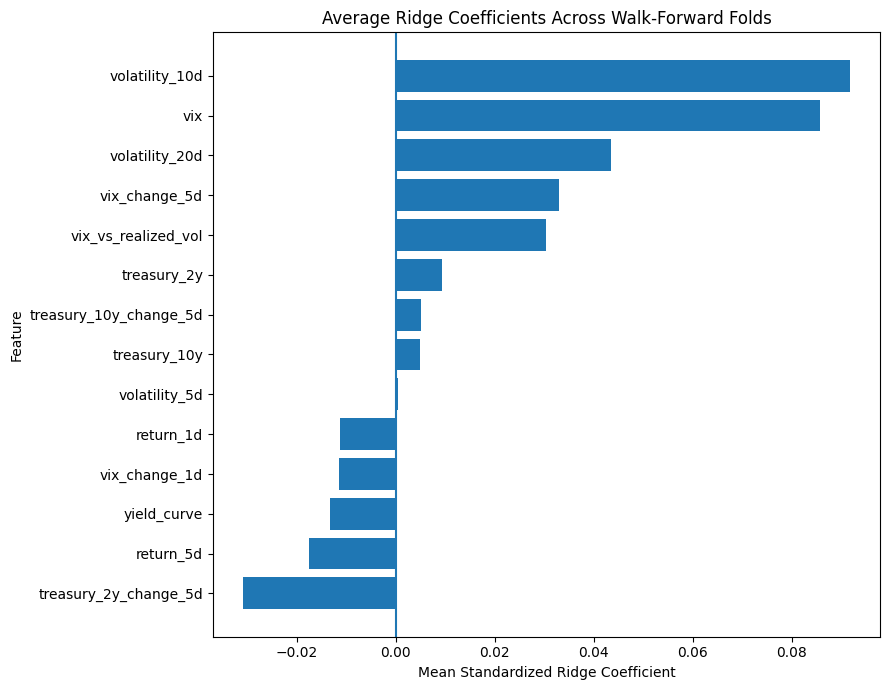

In [5]:
plot_data = (
    coefficient_summary
    .sort_values("mean")
)

plt.figure(figsize=(9, 7))

plt.barh(
    plot_data.index,
    plot_data["mean"],
)

plt.axvline(0)

plt.xlabel("Mean Standardized Ridge Coefficient")
plt.ylabel("Feature")
plt.title(
    "Average Ridge Coefficients Across Walk-Forward Folds"
)

plt.tight_layout()
plt.show()

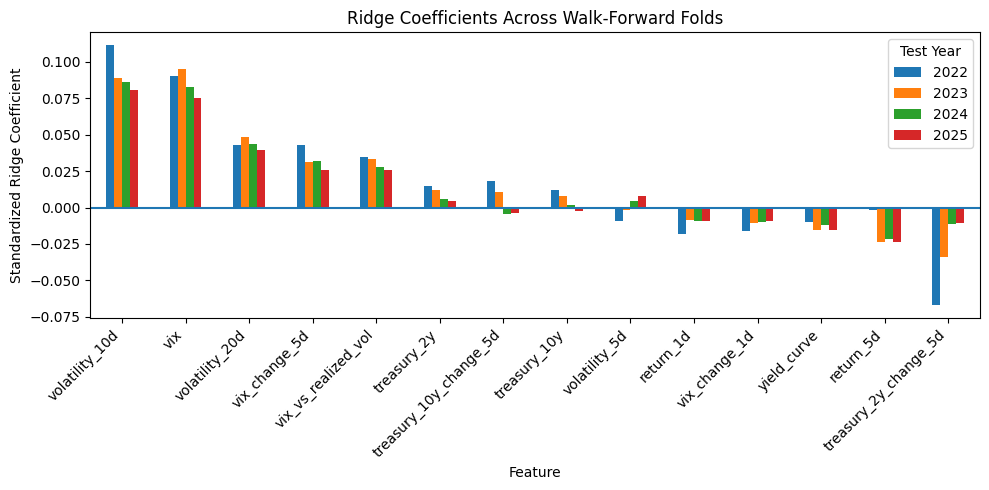

In [15]:
coefficient_pivot = coefficients.pivot(
    index="feature",
    columns="test_year",
    values="coefficient",
)

# Mean coefficient across the walk-forward folds
coefficient_pivot["mean_coefficient"] = (
    coefficient_pivot.mean(axis=1)
)

# Sort from most negative mean coefficient to most positive
coefficient_pivot = coefficient_pivot.sort_values(
    "mean_coefficient",
    ascending=False,
)

# Remove helper column before plotting
plot_data = coefficient_pivot.drop(
    columns="mean_coefficient"
)

plot_data.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.axhline(0)

plt.xlabel("Feature")
plt.ylabel("Standardized Ridge Coefficient")
plt.title(
    "Ridge Coefficients Across Walk-Forward Folds"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.legend(title="Test Year")

plt.tight_layout()
plt.show()

### True vs. Predicted

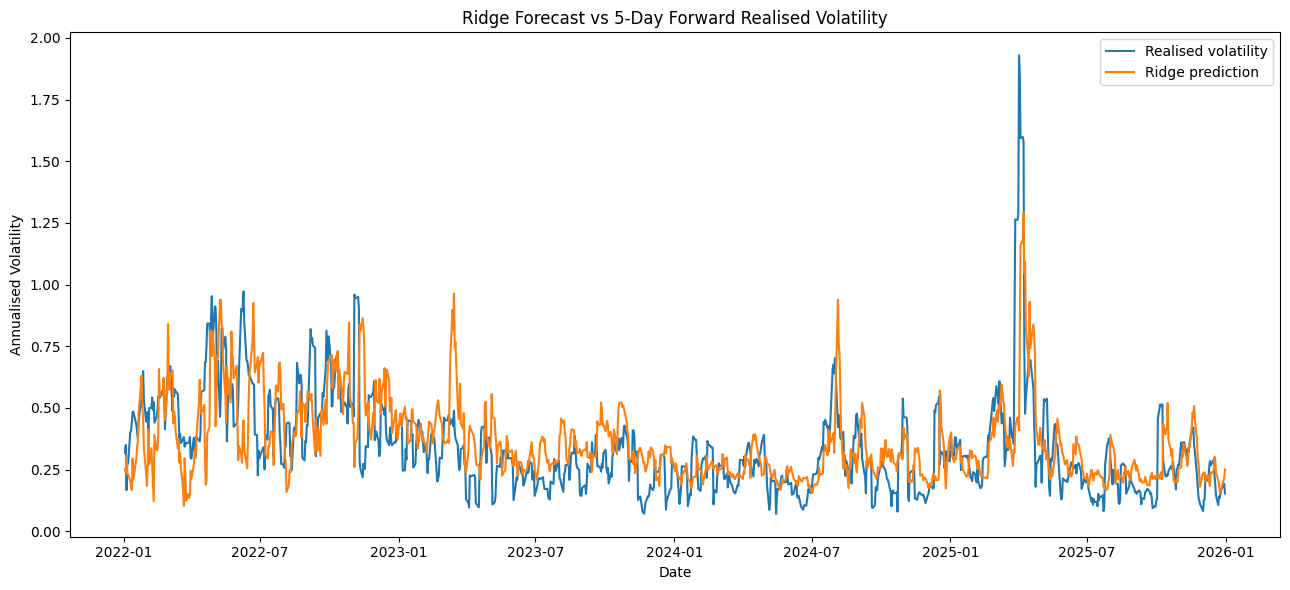

In [6]:
plt.figure(figsize=(13, 6))

plt.plot(
    predictions["date"],
    predictions["y_true"],
    label="Realised volatility",
)

plt.plot(
    predictions["date"],
    predictions["y_pred"],
    label="Ridge prediction",
)

plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.title(
    "Ridge Forecast vs 5-Day Forward Realised Volatility"
)

plt.legend()
plt.tight_layout()
plt.show()